In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [19]:
# Configuración visual
plt.rcParams['figure.figsize'] = (15, 6)
sns.set_theme(style="whitegrid")

# =========================================================
# 0. PREPARACIÓN DE DATOS (Mapeo exacto de tus columnas)
# =========================================================
df = pd.read_csv('outputs/master_dataset.csv', index_col='Time', parse_dates=True)

# 0.1 Promedios Zonales de Temperatura de Suelo (HD3910)
df['T_suelo_R1'] = df.filter(regex='soil_temperature__R1').mean(axis=1)
df['T_suelo_S1'] = df.filter(regex='soil_temperature__S1').mean(axis=1)
df['T_suelo_S2'] = df.filter(regex='soil_temperature__S2').mean(axis=1)

# 0.2 Promedios Zonales de Humedad del Suelo (VWC HD3910)
df['VWC_R1'] = df.filter(regex='soil_vwc__R1').mean(axis=1)
df['VWC_S1'] = df.filter(regex='soil_vwc__S1').mean(axis=1)
df['VWC_S2'] = df.filter(regex='soil_vwc__S2').mean(axis=1)

# 0.3 Promedios Zonales de Radiación PAR (Solo usamos las medidas calibradas 'cal_out')
df['PAR_R1'] = df.filter(regex='par_radiation__R1.*cal_out$').mean(axis=1)
df['PAR_S1'] = df.filter(regex='par_radiation__S1.*cal_out$').mean(axis=1)
df['PAR_S2'] = df.filter(regex='par_radiation__S2.*cal_out$').mean(axis=1)

# 0.4 Variables de control (Meteorología y Ángulos)
df['T_aire_ext'] = df['air_temperature__WS100.Air.TempAvg.degC']
df['Lluvia'] = df['precipitation_intensity__Precipitation Intensity']
df['Angulo_Panel'] = df['tracker_angles__tracker_M01 (actual)'] # Usamos el Tracker M01 como referencia
df['wind_speed'] = df['wind_speed__R1d40_Z8AI.air.WS.kmh']
df['wind_direction'] = df['wind_direction__predominant_wind_direction']

# 0.5 Cálculo de Deltas (Efecto de los paneles)
df['Delta_T_S1'] = df['T_suelo_S1'] - df['T_suelo_R1']
df['Delta_T_S2'] = df['T_suelo_S2'] - df['T_suelo_R1']  
df['Delta_VWC_S1'] = df['VWC_S1'] - df['VWC_R1']
df['Delta_VWC_S2'] = df['VWC_S2'] - df['VWC_R1']

# Variables temporales para agrupaciones
df['Mes'] = df.index.month
df['Hora'] = df.index.hour

C:\Users\pablo\AppData\Local\Temp\ipykernel_10216\125157767.py:27: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['Lluvia'] = df['precipitation_intensity__Precipitation Intensity']
C:\Users\pablo\AppData\Local\Temp\ipykernel_10216\125157767.py:28: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['Angulo_Panel'] = df['tracker_angles__tracker_M01 (actual)'] # Usamos el Tracker M01 como referencia
C:\Users\pablo\AppData\Local\Temp\ipykernel_10216\125157767.py:29: PerformanceWarning: DataFrame is highly fragmented.  This is usuall

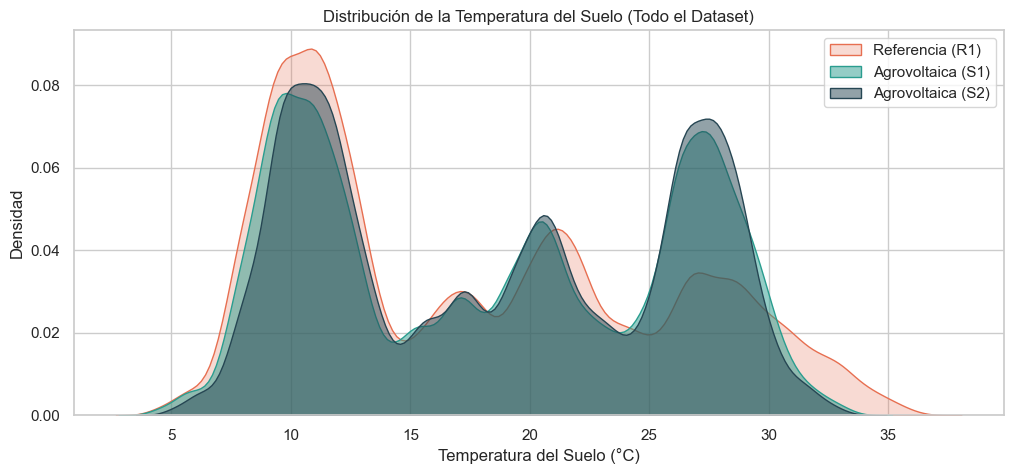

Diferencia media de temp. S1 vs R1: -0.72 °C
Diferencia media de temp. S2 vs R1: -0.47 °C


In [20]:
# Gráfico de densidad de las temperaturas del suelo
plt.figure(figsize=(12, 5))
sns.kdeplot(df['T_suelo_R1'].dropna(), label='Referencia (R1)', color='#E76F51', fill=True)
sns.kdeplot(df['T_suelo_S1'].dropna(), label='Agrovoltaica (S1)', color='#2A9D8F', fill=True, alpha=0.5)
sns.kdeplot(df['T_suelo_S2'].dropna(), label='Agrovoltaica (S2)', color='#264653', fill=True, alpha=0.5)

plt.title('Distribución de la Temperatura del Suelo (Todo el Dataset)')
plt.xlabel('Temperatura del Suelo (°C)')
plt.ylabel('Densidad')
plt.legend()
plt.show()

# Ver el Delta promedio por zona
print(f"Diferencia media de temp. S1 vs R1: {df['Delta_T_S1'].mean():.2f} °C")
print(f"Diferencia media de temp. S2 vs R1: {df['Delta_T_S2'].mean():.2f} °C")

Generando Bloque 1: Análisis Termodinámico...


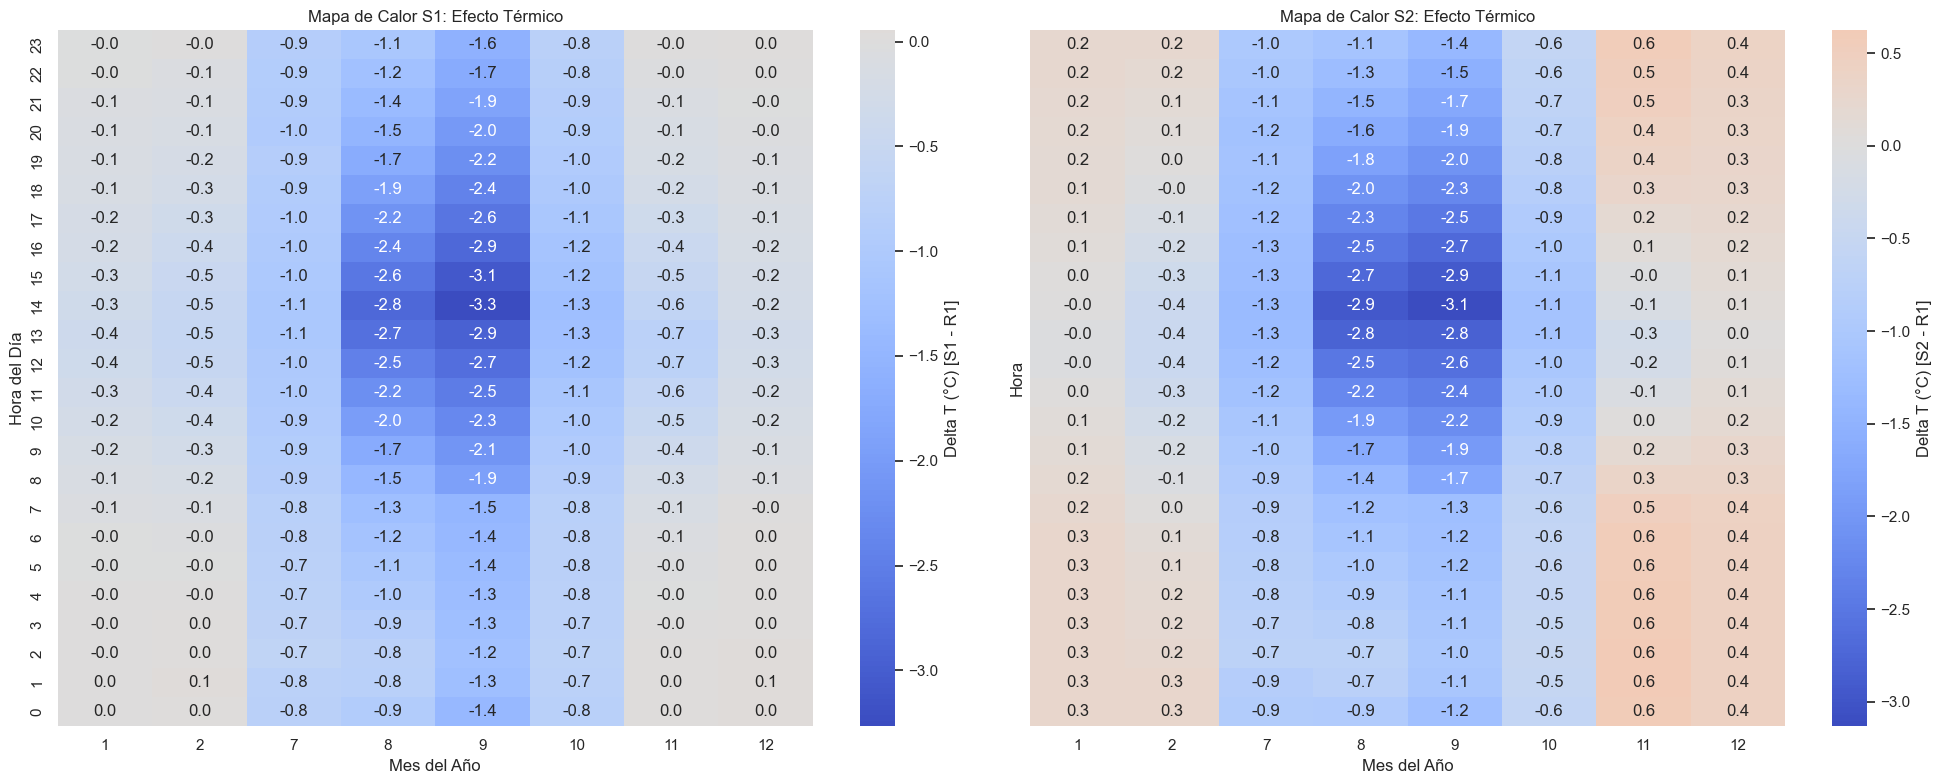

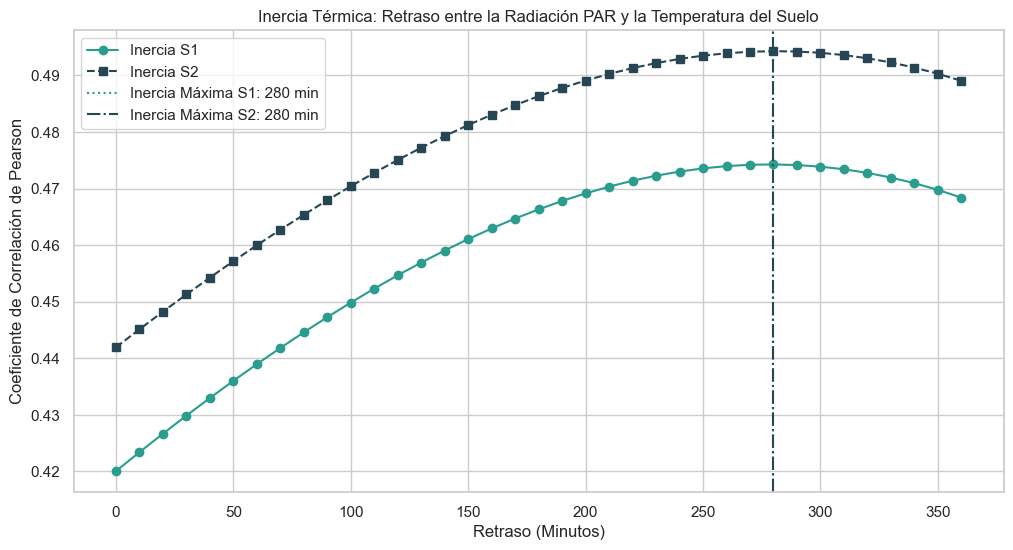

In [21]:
# =========================================================
# BLOQUE 1: MAPAS DE CALOR E INERCIA TÉRMICA (S1 y S2)
# =========================================================
print("Generando Bloque 1: Análisis Termodinámico...")

# 1.1 Mapas de Calor
heatmap_data_s1 = df.pivot_table(values='Delta_T_S1', index='Hora', columns='Mes', aggfunc='mean')
heatmap_data_s2 = df.pivot_table(values='Delta_T_S2', index='Hora', columns='Mes', aggfunc='mean')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8), sharey=True)

sns.heatmap(heatmap_data_s1, cmap='coolwarm', center=0, annot=True, fmt=".1f", 
            cbar_kws={'label': 'Delta T (°C) [S1 - R1]'}, ax=ax1)
ax1.set_title('Mapa de Calor S1: Efecto Térmico')
ax1.set_ylabel('Hora del Día')
ax1.set_xlabel('Mes del Año')
ax1.invert_yaxis()

sns.heatmap(heatmap_data_s2, cmap='coolwarm', center=0, annot=True, fmt=".1f", 
            cbar_kws={'label': 'Delta T (°C) [S2 - R1]'}, ax=ax2)
ax2.set_title('Mapa de Calor S2: Efecto Térmico')
ax2.set_xlabel('Mes del Año')
ax2.invert_yaxis()

plt.tight_layout()
plt.show()

# 1.2 Inercia Térmica (Correlación Cruzada)
df_10m = df[['PAR_S1', 'T_suelo_S1', 'PAR_S2', 'T_suelo_S2']].resample('10min').mean().dropna()

lags = range(0, 37) # 6 horas de ventana
minutos_desfase = [lag * 10 for lag in lags]

corr_s1 = [df_10m['PAR_S1'].corr(df_10m['T_suelo_S1'].shift(-lag)) for lag in lags]
corr_s2 = [df_10m['PAR_S2'].corr(df_10m['T_suelo_S2'].shift(-lag)) for lag in lags]

lag_max_s1 = np.argmax(corr_s1)
lag_max_s2 = np.argmax(corr_s2)

plt.figure(figsize=(12, 6))
plt.plot(minutos_desfase, corr_s1, marker='o', color='#2A9D8F', label='Inercia S1')
plt.plot(minutos_desfase, corr_s2, marker='s', color='#264653', linestyle='--', label='Inercia S2')
plt.axvline(x=minutos_desfase[lag_max_s1], color='#2A9D8F', linestyle=':', label=f'Inercia Máxima S1: {minutos_desfase[lag_max_s1]} min')
plt.axvline(x=minutos_desfase[lag_max_s2], color='#264653', linestyle='-.', label=f'Inercia Máxima S2: {minutos_desfase[lag_max_s2]} min')

plt.title('Inercia Térmica: Retraso entre la Radiación PAR y la Temperatura del Suelo')
plt.xlabel('Retraso (Minutos)')
plt.ylabel('Coeficiente de Correlación de Pearson')
plt.legend()
plt.show()

Generando Bloque 2: Huella Óptica...


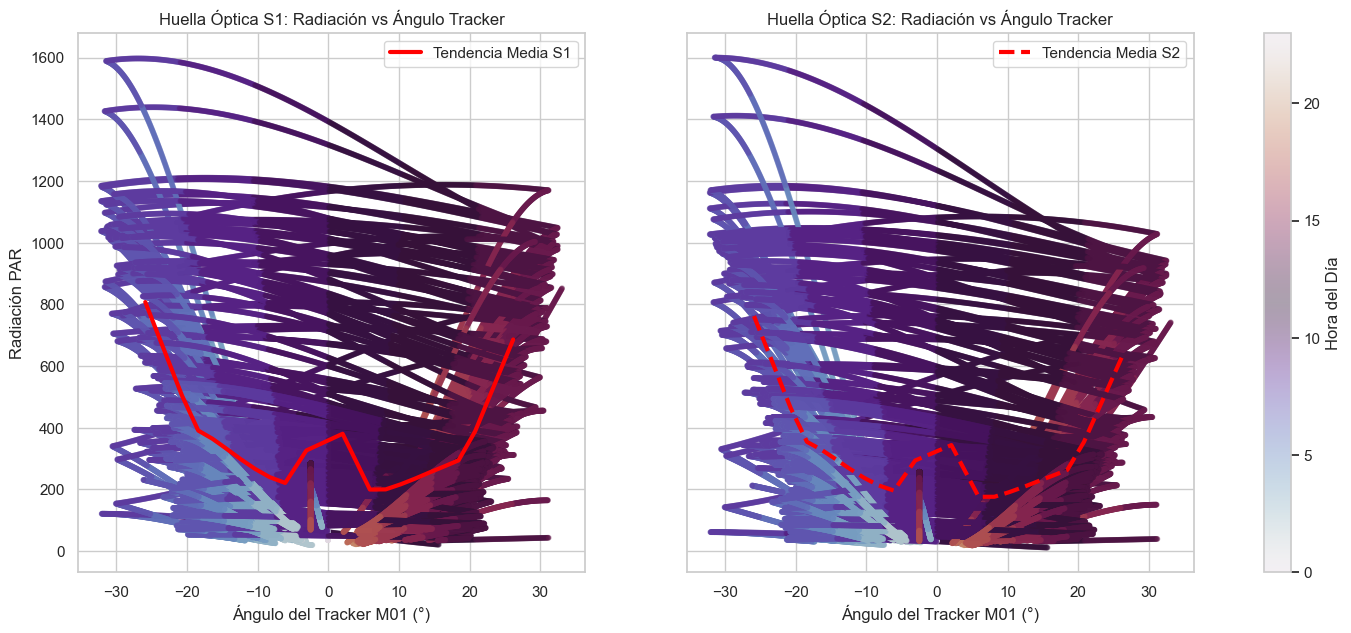

In [22]:
# =========================================================
# BLOQUE 2: GEOMETRÍA DE SOMBRAS (HUELLA ÓPTICA S1 y S2)
# =========================================================
print("Generando Bloque 2: Huella Óptica...")

df_dia = df[df['PAR_R1'] > 50].dropna(subset=['Angulo_Panel', 'PAR_S1', 'PAR_S2', 'Hora'])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7), sharey=True)

# Subplot 1 (S1)
scatter1 = ax1.scatter(df_dia['Angulo_Panel'], df_dia['PAR_S1'], c=df_dia['Hora'], cmap='twilight', alpha=0.4, s=10)
ax1.set_title('Huella Óptica S1: Radiación vs Ángulo Tracker')
ax1.set_xlabel('Ángulo del Tracker M01 (°)')
ax1.set_ylabel('Radiación PAR')

bins_angulos = pd.qcut(df_dia['Angulo_Panel'], q=20, duplicates='drop')
x_medias = df_dia.groupby(bins_angulos)['Angulo_Panel'].mean()
media_por_angulo_s1 = df_dia.groupby(bins_angulos)['PAR_S1'].mean()
ax1.plot(x_medias, media_por_angulo_s1, color='red', linewidth=3, label='Tendencia Media S1')
ax1.legend(loc='upper right')

# Subplot 2 (S2)
scatter2 = ax2.scatter(df_dia['Angulo_Panel'], df_dia['PAR_S2'], c=df_dia['Hora'], cmap='twilight', alpha=0.4, s=10)
ax2.set_title('Huella Óptica S2: Radiación vs Ángulo Tracker')
ax2.set_xlabel('Ángulo del Tracker M01 (°)')

media_por_angulo_s2 = df_dia.groupby(bins_angulos)['PAR_S2'].mean()
ax2.plot(x_medias, media_por_angulo_s2, color='red', linewidth=3, linestyle='--', label='Tendencia Media S2')
ax2.legend(loc='upper right')

fig.colorbar(scatter1, ax=[ax1, ax2], label='Hora del Día')
plt.show()

Generando Bloque 3: Análisis Hídrico y Viento...


C:\Users\pablo\AppData\Local\Temp\ipykernel_10216\15496062.py:8: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_lluvia['Diferencia_Humedad_S1_S2'] = df_lluvia['VWC_S1'] - df_lluvia['VWC_S2']


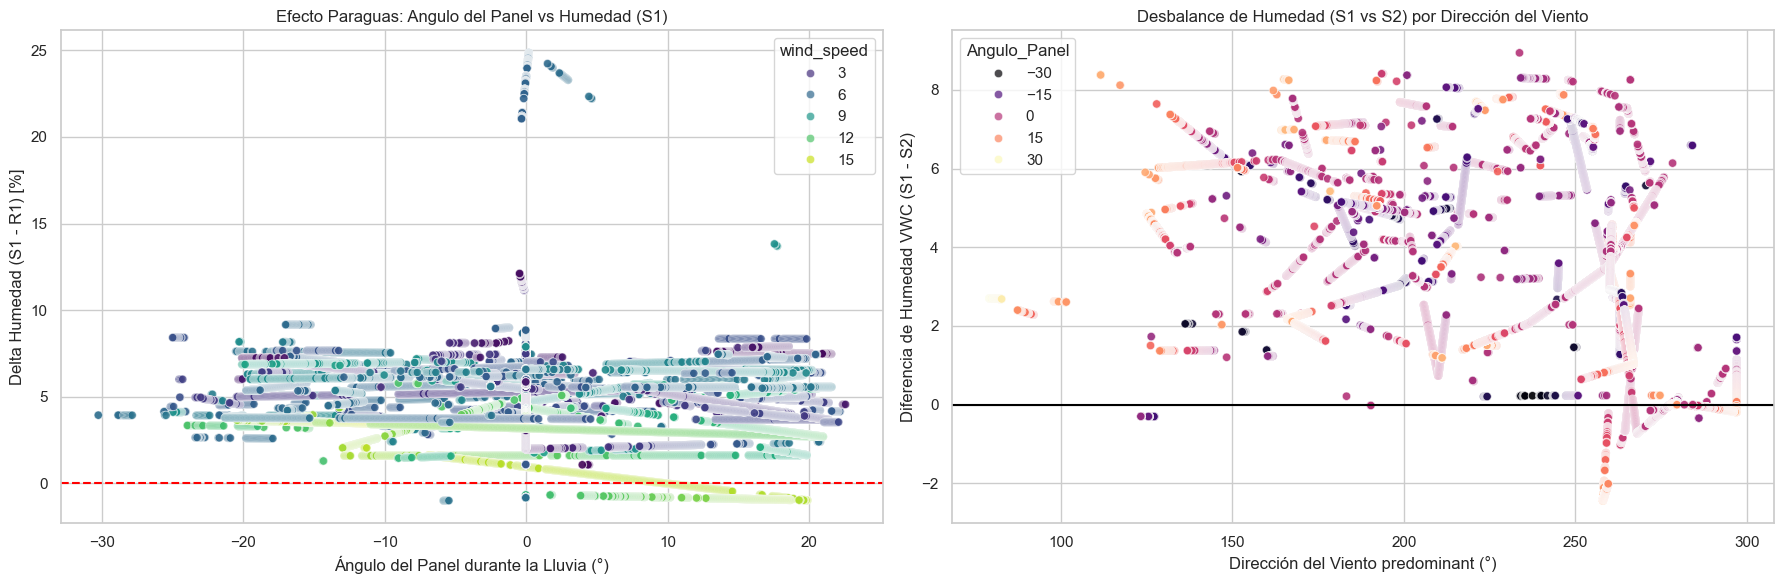


--- Estadísticas de Desbalance Hídrico ---
Lluvias registradas: 20353 periodos de 30s
Correlación Velocidad Viento vs Desbalance S1/S2: -0.422


In [23]:
# =========================================================
# BLOQUE 3: EL EFECTO PARAGUAS Y EL VIENTO (HÍDRICO)
# =========================================================
print("Generando Bloque 3: Análisis Hídrico y Viento...")

# Filtramos estrictamente los momentos con lluvia
df_lluvia = df[df['Lluvia'] > 0.1].dropna(subset=['Angulo_Panel', 'VWC_S1', 'VWC_S2', 'wind_speed', 'wind_direction'])
df_lluvia['Diferencia_Humedad_S1_S2'] = df_lluvia['VWC_S1'] - df_lluvia['VWC_S2']

if not df_lluvia.empty:
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6))

    # Gráfico 1: Humedad S1 frente al ángulo y el viento
    sns.scatterplot(data=df_lluvia, x='Angulo_Panel', y='Delta_VWC_S1', 
                    hue='wind_speed', palette='viridis', alpha=0.7, ax=ax1)
    ax1.axhline(0, color='red', linestyle='--')
    ax1.set_title('Efecto Paraguas: Angulo del Panel vs Humedad (S1)')
    ax1.set_xlabel('Ángulo del Panel durante la Lluvia (°)')
    ax1.set_ylabel('Delta Humedad (S1 - R1) [%]')

    # Gráfico 2: Asimetría S1 vs S2 frente a la dirección del viento
    sns.scatterplot(data=df_lluvia, x='wind_direction', y='Diferencia_Humedad_S1_S2', 
                    hue='Angulo_Panel', palette='magma', alpha=0.7, ax=ax2)
    ax2.axhline(0, color='black', linestyle='-')
    ax2.set_title('Desbalance de Humedad (S1 vs S2) por Dirección del Viento')
    ax2.set_xlabel('Dirección del Viento predominant (°)')
    ax2.set_ylabel('Diferencia de Humedad VWC (S1 - S2)')

    plt.tight_layout()
    plt.show()
    
    print("\n--- Estadísticas de Desbalance Hídrico ---")
    print(f"Lluvias registradas: {len(df_lluvia)} periodos de 30s")
    corr_viento = df_lluvia[['Diferencia_Humedad_S1_S2', 'wind_speed']].corr().iloc[0,1]
    print(f"Correlación Velocidad Viento vs Desbalance S1/S2: {corr_viento:.3f}")
else:
    print("No se encontraron suficientes eventos de lluvia en los datos limpios para graficar el Bloque 3.")